In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/weather.csv")


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])


In [ ]:
# ---------- NULL HANDLING ----------
df.fillna(df.median(numeric_only=True), inplace=True)

# ---------- OUTLIER REMOVAL (IQR) ----------
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

for column in ["humidity", "temperature", "wind_speed", "cloud_cover"]:
    df = remove_outliers(column)

print("Dataset size after cleaning:", df.shape)


Dataset size after cleaning: (1440, 6)


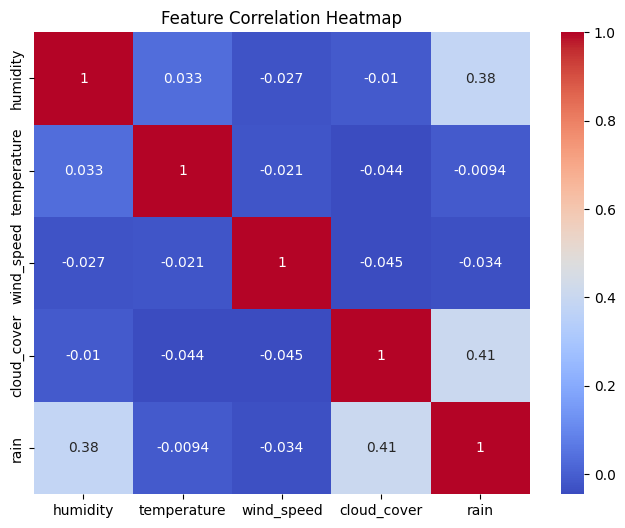

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=["timestamp"]).corr(),
            annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


Accuracy: 0.9555555555555556

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       323
           1       0.86      0.68      0.76        37

    accuracy                           0.96       360
   macro avg       0.91      0.83      0.87       360
weighted avg       0.95      0.96      0.95       360



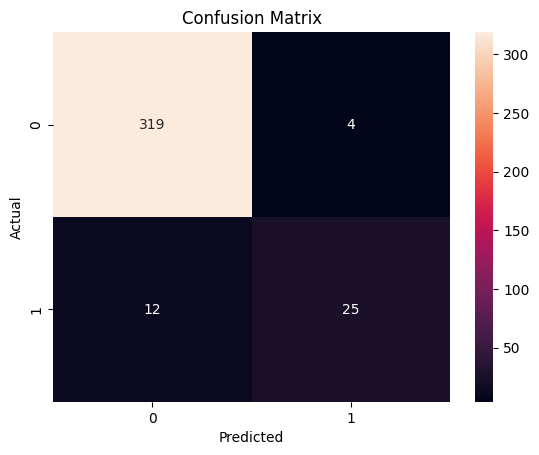

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df[["humidity", "temperature", "wind_speed", "cloud_cover"]]
y = df["rain"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import gradio as gr
import numpy as np

def predict_rain(humidity, temperature, wind_speed, cloud_cover):
    input_data = np.array([[humidity, temperature, wind_speed, cloud_cover]])

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    if prediction == 1:
        return f"🌧️ Rain Likely ({probability*100:.2f}% probability)"
    else:
        return f"☀️ No Rain ({(1-probability)*100:.2f}% probability)"

interface = gr.Interface(
    fn=predict_rain,
    inputs=[
        gr.Slider(30, 100, value=70, label="Humidity (%)"),
        gr.Slider(15, 45, value=30, label="Temperature (°C)"),
        gr.Slider(0, 30, value=10, label="Wind Speed (km/h)"),
        gr.Slider(0, 100, value=50, label="Cloud Cover (%)"),
    ],
    outputs="text",
    title="🌦️ Rain Prediction System",
    description="Adjust the weather parameters to predict if it will rain today."
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3eb7f31319142a453d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
